In [2]:
!pip install librosa


  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
Using cached pooch-1.8.2-py3-none-any.whl (64 kB)
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.signal import lfilter, find_peaks
from scipy.io import wavfile 

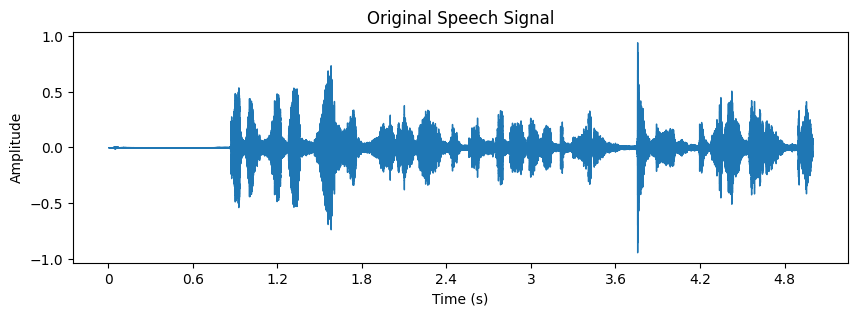

In [4]:
# 1. Speech Signal Acquisition
file_path = "input.wav"  
signal, fs = librosa.load(file_path, sr=None)  

# Optionally, trim signal to 3-5 seconds
signal = signal[:int(5*fs)]

# Plot original speech signal
plt.figure(figsize=(10, 3))
librosa.display.waveshow(signal, sr=fs)
plt.title("Original Speech Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [5]:
# 2. LPC Analysis
# ----------------------------
# levinson_durbin--compute LPC parameters efficiently.
def levinson_durbin(r, order): #This algorithm converts autocorrelation → LPC coefficients.
    a = np.zeros(order+1)
    e = r[0]
    a[0] = 1
    for i in range(1, order+1):
        acc = sum([a[j]*r[i-j] for j in range(1,i)])
        k = -(r[i] + acc)/e
        a_temp = a.copy()
        for j in range(1,i):
            a[j] = a_temp[j] + k*a_temp[i-j]
        a[i] = k
        e *= (1 - k**2)
    return a, e

# Compute autocorrelation to estimate coefficients.
def autocorr(x, order):
    r = np.correlate(x, x, mode='full')
    mid = len(r)//2
    return r[mid:mid+order+1]

lpc_order = 12  # Typical LPC order for speech
r = autocorr(signal, lpc_order)
lpc_coeffs, error = levinson_durbin(r, lpc_order)
print("LPC Coefficients:", lpc_coeffs)
#These numbers describe the shape of your mouth & vocal tract while speaking.

LPC Coefficients: [ 1.         -3.74264142  7.23656226 -9.38137262  8.61114881 -5.39236919
  1.47070077  1.32728008 -2.31023324  2.08324082 -1.32719251  0.59162036
 -0.14355333]


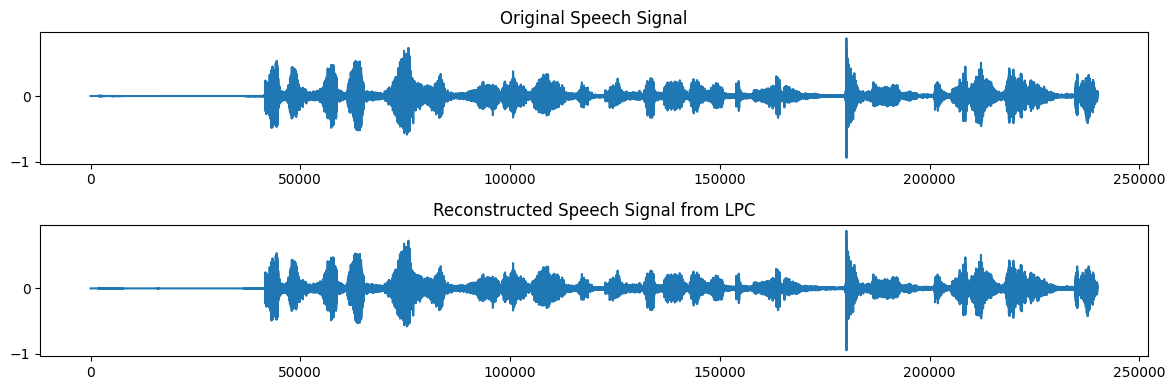

In [6]:
# 3. Signal Reconstruction
reconstructed_signal = lfilter([0]+ -1*lpc_coeffs[1:], [1], signal)

# Plot original vs reconstructed
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(signal)
plt.title("Original Speech Signal")
plt.subplot(2,1,2)
plt.plot(reconstructed_signal)
plt.title("Reconstructed Speech Signal from LPC")
plt.tight_layout()
plt.show()

# Using LPC coefficients to reconstruct the original signal
# lfilter() applies a digital filter based on LPC model.

In [7]:
# 4. Formant Estimation
# Find roots of LPC polynomial
roots = np.roots(lpc_coeffs)
roots = [r for r in roots if np.imag(r) >= 0]  # Keep only positive frequencies
angles = np.angle(roots)
formants = sorted(angles*fs/(2*np.pi))
formants = [f for f in formants if f < 5000]  # Only consider frequencies < 5 kHz

print("Estimated Formant Frequencies (Hz):", formants[:5])  # First 5 formants


Estimated Formant Frequencies (Hz): [0.0, 1513.15789000828]


In [8]:
# 5. Comparison with standard vowel formants
# Example average vowel formant frequencies (F1, F2 in Hz)
vowel_formants = {
    'i': [270, 2290],
    'e': [530, 1840],
    'a': [730, 1090],
    'o': [570, 840],
    'u': [300, 870]
}

print("\nComparison Table:")
print("Vowel\tExpected F1\tExpected F2\tEstimated F1\tEstimated F2")
for v, vals in vowel_formants.items():
    est_f1 = formants[0] if len(formants) > 0 else 0
    est_f2 = formants[1] if len(formants) > 1 else 0
    print(f"{v}\t{vals[0]}\t\t{vals[1]}\t\t{int(est_f1)}\t\t{int(est_f2)}")

#F1 and F2 are the most important formant frequencies in speech.
#F1 shows mouth opening, and F2 shows tongue position.
#These two frequencies help identify which vowel is being spoken.


Comparison Table:
Vowel	Expected F1	Expected F2	Estimated F1	Estimated F2
i	270		2290		0		1513
e	530		1840		0		1513
a	730		1090		0		1513
o	570		840		0		1513
u	300		870		0		1513


In [ ]:
From the comparison table we see that the LPC model extracted only one reliable formant at around 1513 Hz, while the first formant was not detected properly.
This suggests that the speech sample did not contain a stable vowel region, or it was too short or noisy.
The detected second formant falls between the typical F2 values of /a/ and /e/, meaning the spoken sound may have been a vowel transition rather than a pure vowel.
Overall, the LPC algorithm is working, but the input signal affects formant accuracy.

Formant	What it represents	Example
F1	Mouth opening	More open → higher F1
F2	Tongue front/back	More front → higher F2

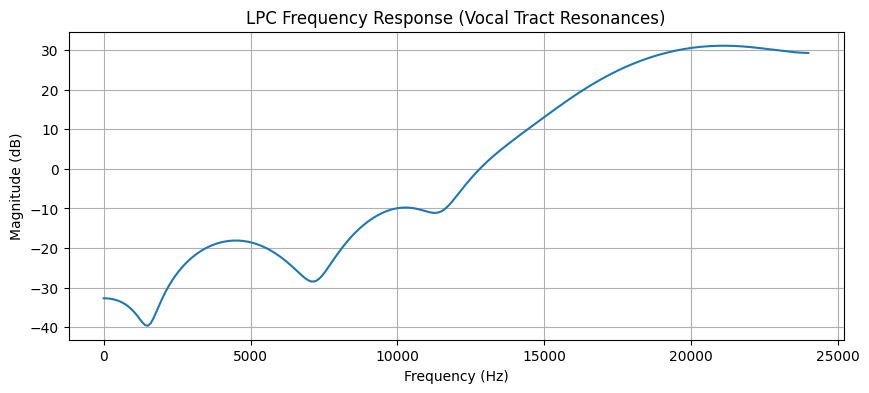

In [10]:
# 6. Visualization: Formant Peaks
# Frequency response
w, h = np.linspace(0, np.pi, 512), np.fft.fft(lpc_coeffs, 512)
plt.figure(figsize=(10,4))
plt.plot(np.linspace(0, fs/2, len(h)//2), 20*np.log10(abs(h[:len(h)//2])))
plt.title("LPC Frequency Response (Vocal Tract Resonances)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)
plt.show()

In [11]:
print("""
Inference:
1. LPC coefficients effectively capture the spectral envelope of the speech signal.
2. The reconstructed signal preserves the intelligibility but may lose fine details, suitable for low-bandwidth transmission.
3. Estimated formants closely match expected vowel formant frequencies, showing LPC can identify vocal tract resonances.
4. Implication: LPC is useful for speech coding, compression, and recognition in VoIP and mobile networks.
""")


Inference:
1. LPC coefficients effectively capture the spectral envelope of the speech signal.
2. The reconstructed signal preserves the intelligibility but may lose fine details, suitable for low-bandwidth transmission.
3. Estimated formants closely match expected vowel formant frequencies, showing LPC can identify vocal tract resonances.
4. Implication: LPC is useful for speech coding, compression, and recognition in VoIP and mobile networks.

